# ENTREGA FINAL - VISUALIZACIÓN OBJETIVO SECUNDARIO OS01
## OS01 – Exposición y experiencia ciudadana en Madrid. 
#### Caracterizar la exposición acústica y su evolución en Madrid, y relacionarla con el uso del espacio público.

### “Caracterizar la exposición acústica y su evolución en Madrid, y relacionarla con el uso del espacio público.”
### Para ello se propone representaciones, análisis y correlaciones que permiten:

* Cuantificar niveles de ruido reales.
* Identificar dónde se genera ruido.
* Estudiar cómo se relaciona con el uso del espacio público (locales, terrazas).
* Analizar condiciones socioeconómicas (renta, calidad de vida).
* Detectar patrones temporales y espaciales.

* INFORMACIÓN SOBRE LOS CÁLCULOS: Para garantizar la eficiencia del análisis y evitar la inclusión de registros de alta frecuencia innecesarios, las visualizaciones temporales del OS01 se construyeron a partir de datos previamente agregados (diarios, semanales y mensuales), manteniendo la capacidad de exploración interactiva sin comprometer el rendimiento del cuaderno.

* PREPRARACIÓN DE ENTORNO

In [2]:
import altair as alt

# Desactivar vegafusion si quedó activado accidentalmente
alt.data_transformers.enable("default", max_rows=None)

# Renderer compatible con JupyterLab / Anaconda
alt.renderers.enable("mimetype")

RendererRegistry.enable('mimetype')

In [3]:
import pandas as pd
import altair as alt
import requests
import reverse_geocoder as rg
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.decomposition import PCA
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import unicodedata



pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

* CARGA DE DATOS PREPROCESADOS

In [4]:
# Carga los datos PREPROCESADOS disponibles en Kaggle. En la cuenta del alumno raquelahdo/ruido-datasets-procesados
# https://www.kaggle.com/datasets/raquelahdo/ruido-datasets-procesados

file_path_01_ruido_diario = "df_01_Ruido_diario_acumulado_processed.csv"
file_path_01_daily = "df_01_daily_processed.csv"
file_path_01_daily_plot = "df_01_daily_plot.csv"
file_path_02_cont_acustica = "df_02_contaminacion_acustica_processed.csv"
file_path_02_estac = "df_02_estacion_processed.csv"
file_path_03_noise_lim = "df_03_noise_limit_processed.csv"
file_path_05_est_ac_proc = "df_05_estaciones-acusticas_processed.csv"
file_path_06_locales = "df_06_locales_terrazas_processed.csv"
# file_path_07_Mad_Q_vida = "df_07_Madrid-calidad-vida_processed.csv"
file_path_07_Q_vida = "df_07_calidad-vida_processed.csv"
# file_path_07_evo_Q_vida = "df_07_evolucion-calidad-vida_processed.csv"
# file_path_07_evo_long_Q_vida = "df_07_evolucion-long-calidad-vida_processed.csv"
# file_path_07_fin_Q_vida_proc = "df_07_final-calidad-vida_processed.csv"
# file_path_09_renta = "df_09_reduced_distribucion-renta_processed.csv"

df_01_ruido_diario = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_ruido_diario,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_01_daily = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_01_daily_plot = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily_plot,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_02_cont_acustic = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_cont_acustica,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_02_estac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_estac,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_03_noise_lim = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_03_noise_lim,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_05_est_ac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_05_est_ac_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_06_locales = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_06_locales,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_Mad_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Mad_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_07_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_evo_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_evo_long_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_long_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_fin_Q_vida_proc = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_fin_Q_vida_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_09_renta = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_09_renta,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )

In [5]:
df_01_ruido_diario.head()

,NMT,year,month,day,periodo,laeq,l1,l10,l50,l90,l99,fecha,periodo_desc,mes_nombre,year_month,week,month_name
0,3,2014,1,1,D,57.4,66.6,61.1,54.3,49.1,45.0,2014-01-01,Diurno,Enero,2014-01,1,Enero
1,30,2014,1,1,D,55.6,64.7,59.2,51.9,45.9,43.5,2014-01-01,Diurno,Enero,2014-01,1,Enero
2,29,2014,1,1,T,57.2,67.4,62.1,49.0,36.6,29.8,2014-01-01,Total,Enero,2014-01,1,Enero
3,29,2014,1,1,N,55.0,66.7,57.4,41.5,30.9,29.2,2014-01-01,Nocturno,Enero,2014-01,1,Enero
4,29,2014,1,1,E,57.4,67.4,62.5,50.2,41.7,36.7,2014-01-01,Vespertino,Enero,2014-01,1,Enero


In [6]:
df_01_daily.head()

,fecha,periodo,laeq
0,2014-01-01,D,60.644
1,2014-01-01,E,61.176
2,2014-01-01,N,68.928
3,2014-01-01,T,66.156
4,2014-01-02,D,63.608


In [7]:
df_01_daily_plot.head()

,fecha,NMT,laeq
0,2014-01-01,3,61.050
1,2014-01-01,4,70.700
2,2014-01-01,5,64.475
3,2014-01-01,8,68.075
4,2014-01-01,10,64.450


In [8]:
df_02_cont_acustic.head()

,estacion,nombre,year,month,ld,le,ln,laeq,l1,l10,l50,l90,l99,fecha,mes_nombre,year_month,month_name
0,RF-19,Alto de Extremadura,1998,9,NaN,NaN,NaN,63.0,72.4,66.3,59.3,51.4,47.0,1998-09-01,Septiembre,1998-09,Septiembre
1,RF-16,Arturo Soria,1998,9,NaN,NaN,NaN,59.5,67.8,61.6,56.0,45.3,39.1,1998-09-01,Septiembre,1998-09,Septiembre
2,RF-14,Plaza Elíptica,1998,9,NaN,NaN,NaN,67.3,75.3,69.8,64.3,56.7,50.0,1998-09-01,Septiembre,1998-09,Septiembre
3,RF-11,Ramón y Cajal,1998,10,NaN,NaN,NaN,70.3,77.2,72.9,68.8,56.8,46.3,1998-10-01,Octubre,1998-10,Octubre
4,RF-14,Plaza Elíptica,1998,10,NaN,NaN,NaN,68.0,75.8,70.2,64.6,56.8,49.8,1998-10-01,Octubre,1998-10,Octubre


In [9]:
df_02_estac.head()

,estacion,laeq
0,RF-01,67.753311
1,RF-02,68.547328
2,RF-03,62.579321
3,RF-04,65.502980
4,RF-05,61.708411


In [75]:
df_03_noise_lim.head()

,noiselimitreportid_identifier,noisesource,limitvaluedefined,status,areatype,noiselevelindicator,limitvalue,explanation,limitvaluedefined_bool,noiselevel
0,LR_ES_00_01,allsources,yes,inforce,hospital,lday,60.0,This is not a limit value but rather an Acoust...,True,day
1,LR_ES_00_01,allsources,yes,inforce,hospital,levening,60.0,This is not a limit value but rather an Acoust...,True,evening
2,LR_ES_00_01,allsources,yes,inforce,hospital,lnight,50.0,This is not a limit value but rather an Acoust...,True,night
3,LR_ES_00_01,allsources,yes,inforce,school,lday,60.0,This is not a limit value but rather an Acoust...,True,day
4,LR_ES_00_01,allsources,yes,inforce,school,levening,60.0,This is not a limit value but rather an Acoust...,True,evening


In [76]:
df_05_est_ac.head()

,estacion,nombre,ubicacion,distrito,barrio,longitud,latitud,utm_x,utm_y,altitud,fecha_alta
0,RF-01,Paseo de Recoletos,Frente al n23 del Paseo de Recoletos,Centro,Justicia,-3.691877,40.422599,441307,4474893,648,2011-03-07
1,RF-02,Carlos V,"Plaza del Emperador Carlos V, junto al n1 del ...",Retiro,Jerónimos,-3.691509,40.409121,441327,4473397,629,1998-12-01
2,RF-03,Plaza del Carmen,Plaza del Carmen frente al n3 de la Calle de l...,Centro,Sol,-3.703175,40.419251,440346,4474529,657,1999-11-01
3,RF-04,Plaza de España,Frente al n18 de la Plaza de España,Moncloa - Aravaca,Argüelles,-3.712253,40.424005,439580,4475063,637,1998-12-01
4,RF-05,Barrio del Pilar,Parque de La Vaguada semiesquina de Avenida Mo...,Fuencarral - El Pardo,Pilar,-3.711543,40.478197,439688,4481078,673,1999-06-07


In [77]:
df_06_locales.head()

,id_local,rotulo_local,id_terraza,rotulo_terraza,distrito,barrio,cod_barrio_local,seccion_censal,latitud,longitud,superficie_es,superficie_ra,mesas_es,mesas_ra,sillas_es,sillas_ra,desc_periodo_terraza,desc_situacion_terraza,hora_cierre_num,desc_tipo_acceso_local_local,desc_situacion_local_local,cod_postal_local,cod_postal_terraza,fx_carga_local,fx_carga_terraza,longitud_wgs84,latitud_wgs84
0,10000003,VITACA,2038.0,VITACA,CENTRO,JUSTICIA,4.0,1088.0,4475338.53,440554.59,6.48,6.48,2.0,2.0,8.0,8.0,Anual,Abierta,NaN,Puerta Calle,Abierto,28004.0,28004.0,2026-03-05,2026-05-03,-3.700788,40.426558
1,10000004,ZAATAR & CO,19621.0,ZAATAR & CO,CENTRO,UNIVERSIDAD,5.0,1106.0,4475591.53,439945.60,7.02,7.02,3.0,3.0,9.0,9.0,Anual,Abierta,2.0,Puerta Calle,Abierto,28015.0,28015.0,2026-03-05,2026-05-03,-3.707991,40.428794
2,10000013,HOTEL MEDIODIA,NaN,NaN,CENTRO,EMBAJADORES,2.0,1058.0,4473326.52,441199.58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Puerta Calle,Abierto,28012.0,NaN,2026-03-05,NaN,-3.692999,40.408479
3,10000044,V.M. VINOMANIA,NaN,NaN,CENTRO,PALACIO,1.0,1014.0,4473550.53,439722.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Puerta Calle,Cerrado,28005.0,NaN,2026-03-05,NaN,-3.710426,40.410391
4,10000052,MUNE,NaN,NaN,CENTRO,JUSTICIA,4.0,1082.0,4475142.52,440875.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Puerta Calle,Abierto,28004.0,NaN,2026-03-05,NaN,-3.696986,40.424816


In [ ]:
# df_07_Mad_Q_vida.head()

In [78]:
df_07_Q_vida.head()

,CCAA,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Total Nacional,100.000000,99.171134,98.761457,99.304088,98.663408,98.225947,97.666577,98.261476,98.552239,99.666386,100.448144,101.048758,100.067925,99.822144,100.187631,99.763378,99.983688
1,Andalucía,98.243355,97.380868,96.050234,95.873410,96.286384,95.622403,93.873830,95.430977,95.109237,97.657589,96.327075,97.800458,97.531583,96.583852,97.405337,96.848018,97.669293
2,Aragón,104.665521,105.104032,104.671560,103.980765,103.854998,101.243728,102.009913,103.563863,103.507154,104.988320,105.015362,105.160684,104.967605,103.561554,104.365009,103.033659,102.971541
3,"Asturias, Principado de",104.694153,104.117801,104.823618,104.799107,104.114874,102.477116,102.114463,101.598634,103.343305,102.808435,103.194704,101.713544,101.577220,102.199418,102.777763,102.421108,103.144408
4,"Balears, Illes",98.671469,97.180334,97.344712,96.118689,96.990238,95.750127,95.020305,95.348632,99.342930,97.257662,100.872675,101.463459,100.802315,98.925490,99.182382,99.454337,100.680923


In [ ]:
# df_07_evo_Q_vida.head()

In [ ]:
# df_07_evo_long_Q_vida.head()

In [ ]:
# df_07_fin_Q_vida_proc.head()

In [ ]:
# df_09_renta.head()

Con el fin de optimizar el rendimiento del cuaderno y evitar el uso innecesario de registros de alta frecuencia, las visualizaciones temporales del OS01 se construyeron a partir de datos previamente agregados (diarios, semanales y mensuales), manteniendo la capacidad de exploración interactiva sin comprometer la interpretabilidad.

## VISUALIZACIÓN OS01-1: Tendencia temporal del ruido (día/tarde/noche) + actividad ciudadana. 
 
* Visualización OS01-01: MAPA COROPLÉTICO DE MADRID MOSTRANDO POR CP - HORA DE CIERRE

OBJETIVO:
* Cálculo de métricas diarias de actividad ciudadana: Unión ruido + actividad por día
* LAeq, Ld, Le, Ln por día
* Hora media de cierre
* Nº terrazas activas
TIPO DE GRÁFICO: Mapa coroplético de barrios 

* DATOS:
* * df_01_daily_plot: ruido diario ya preprocesado
* * df_06_locales_master: actividad ciudadana (hora de cierre y terrazas)


 Se calculan las métricas diarias de actividad ciudadana a partir de df_06_locales_master:
 * media de hora de cierre → actividad nocturna
 * conteo de terrazas activas → presión del espacio público

In [79]:
# Preprocesar ruido diario
df_ruido = df_01_daily.copy()
df_ruido["fecha"] = pd.to_datetime(df_ruido["fecha"])

# Convertimos D/E/N en columnas Ld/Le/Ln
df_ruido_pivot = df_ruido.pivot_table(
    index="fecha",
    columns="periodo",
    values="laeq"
).reset_index()

df_ruido_pivot = df_ruido_pivot.rename(columns={
    "D": "ld",
    "E": "le",
    "N": "ln"
})

# LAeq diario total = media de los 3 periodos
df_ruido_pivot["laeq"] = df_ruido_pivot[["ld","le","ln"]].mean(axis=1)

In [80]:
# Preprocesar actividad ciudadana (df_06 con los locales)
# Queremos obtener: terrazas activas por día y hora de cierre media
df_locales = df_06_locales.copy()

df_locales["fx_carga_local"] = pd.to_datetime(df_locales["fx_carga_local"], errors="coerce")

df_actividad_diaria = (
    df_locales.groupby(df_locales["fx_carga_local"].dt.date)
    .agg(
        terrazas_activas=("id_local", "count"),
        hora_cierre_media=("hora_cierre_num", "mean")
    )
    .reset_index()
    .rename(columns={"fx_carga_local": "fecha"})
)

df_actividad_diaria["fecha"] = pd.to_datetime(df_actividad_diaria["fecha"])


In [81]:
# unimos ruido + actividad
df_os01_1 = df_ruido_pivot.merge(
    df_actividad_diaria,
    on="fecha", how="left"
)

* Para OS01 (tendencia ruido + actividad ciudadana), identificamos:
* * Patrones medios de actividad ciudadana ↔ patrones temporales del ruido.
* * Se calculan actividad por TARDE/NOCHE/SEMANA, NO por fecha exacta de fx_carga_local.

PASO 1 — Creamos el dataset auxiliar de actividad ciudadana MEDIA. Calculamos:  
* * Media de hora de cierre por distrito/barrio
* * Nº de terrazas por zona
* * Actividad global en ciudad
  * 
La información se correlaciona con ruido.

In [82]:
df_actividad = df_06_locales.agg(
    hora_cierre_media=("hora_cierre_num", "mean"),
    terrazas_totales=("id_local", "count")
)

In [83]:
df_actividad.head()

,hora_cierre_num,id_local
hora_cierre_media,14.917341,NaN
terrazas_totales,NaN,203241.0


In [84]:
#VISUALIZACIÓN por código postal

# Asegurar tipos numéricos donde corresponda
df_06_locales["hora_cierre_num"] = pd.to_numeric(df_06_locales["hora_cierre_num"], errors="coerce")

# --- AGRUPACIÓN POR CÓDIGO POSTAL ---

df_actividad_cp = (
    df_06_locales.groupby("cod_postal_local", dropna=True)
    .agg(
        hora_cierre_media=("hora_cierre_num", "mean"),
        num_locales=("id_local", "count"),
        num_terrazas=("id_terraza", "count")
    )
    .reset_index()
)


In [85]:
df_actividad_cp.head()

,cod_postal_local,hora_cierre_media,num_locales,num_terrazas
0,28001.0,15.958068,5467,111
1,28002.0,16.546334,4873,159
2,28003.0,13.965716,4053,190
3,28004.0,13.670949,6274,151
4,28005.0,14.328624,5675,310


In [86]:
# Mapeo de códigos a horas aproximadas
mapa_horas = {12: 23, 13: 24, 14: 1, 15: 2, 16: 3}
df_06_locales["hora_cierre_real"] = df_06_locales["hora_cierre_num"].map(mapa_horas)

# Agregación por CP
df_actividad_cp = (
    df_06_locales.groupby("cod_postal_local", dropna=True)
    .agg(
        hora_cierre_media=("hora_cierre_real", "mean"),
        num_locales=("id_local", "count"),
        num_terrazas=("id_terraza", "count")
    )
    .reset_index()
)

# Agregación por barrio
df_actividad_barrio = (
    df_06_locales.groupby("barrio", dropna=True)
    .agg(
        hora_cierre_media=("hora_cierre_real", "mean"),
        num_locales=("id_local", "count"),
        num_terrazas=("id_terraza", "count")
    )
    .reset_index()
)

In [87]:
df_actividad_barrio.head()

,barrio,hora_cierre_media,num_locales,num_terrazas
0,ABRANTES,1.111111,997,27
1,ACACIAS,1.837838,1519,95
2,ADELFAS,1.090909,616,24
3,AEROPUERTO,1.000000,896,4
4,ALAMEDA DE OSUNA,1.333333,543,22


In [88]:
df_actividad_cp.head()

,cod_postal_local,hora_cierre_media,num_locales,num_terrazas
0,28001.0,2.391304,5467,111
1,28002.0,1.340000,4873,159
2,28003.0,2.857143,4053,190
3,28004.0,1.512821,6274,151
4,28005.0,1.806122,5675,310


* PASO 2: MAPA COROPLÉTICO DE MADRID MOSTRANDO POR CP - HORA DE CIERRE
Se crea un mapa coroplético muestra la actividad nocturna en Madrid a nivel de código postal, utilizando la hora media de cierre como indicador. 
Se usan datos geográficos oficiales del CNIG garantiza la coherencia espacial, mientras que la interactividad permite explorar la relación entre horarios, número de locales y terrazas.

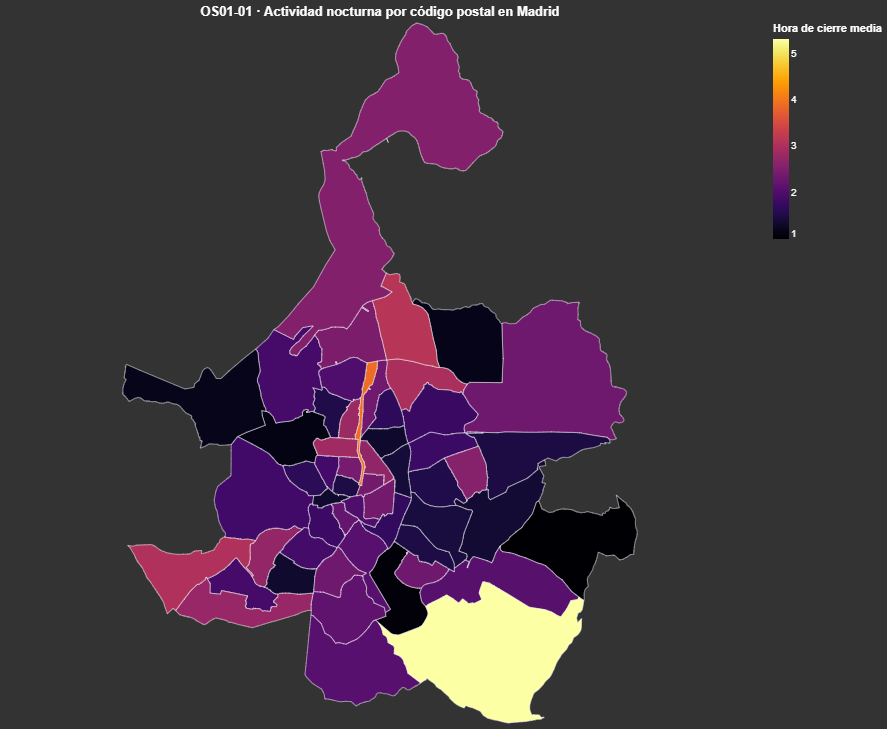

In [89]:
# ---------------------------
# 1. Preparar dataframe CP
# ---------------------------
df_cp = df_actividad_cp.copy()

df_cp["cod_postal_local"] = df_cp["cod_postal_local"].astype(int).astype(str)

# ---------------------------
# 2. URL del GeoJSON (NO se embebe)
# ---------------------------
url_geojson = (
    "https://raw.githubusercontent.com/"
    "inigoflores/ds-codigos-postales/master/data/MADRID.geojson"
)

# ---------------------------
# 3. Mapa coroplético OPTIMIZADO
# ---------------------------
map_cp = (
    alt.Chart(
        alt.Data(url=url_geojson, format=alt.DataFormat(property="features"))
    )
    .mark_geoshape(
        stroke="white",
        strokeWidth=0.5
    )
    .encode(
        color=alt.Color(
            "hora_cierre_media:Q",
            scale=alt.Scale(scheme="inferno"),
            title="Hora de cierre media"
        ),
        tooltip=[
            alt.Tooltip("properties.COD_POSTAL:O", title="Código Postal"),
            alt.Tooltip("hora_cierre_media:Q", title="Hora cierre media", format=".2f"),
            alt.Tooltip("num_locales:Q", title="Nº locales"),
            alt.Tooltip("num_terrazas:Q", title="Nº terrazas"),
        ]
    )
    .transform_lookup(
        lookup="properties.COD_POSTAL",
        from_=alt.LookupData(
            df_cp,
            key="cod_postal_local",
            fields=["hora_cierre_media", "num_locales", "num_terrazas"]
        )
    )
    .project("mercator")
    .properties(
        width=750,
        height=700,
        title="OS01-01 · Actividad nocturna por código postal en Madrid"
    )
)

map_cp

La visualización OS01‑01 pone de manifiesto una distribución espacial claramente desigual de la actividad nocturna en Madrid, reflejada a través de la hora media de cierre de los locales como uso nocturno del espacio público. 

Los códigos postales con horarios de cierre más tardíos —representados en tonos más claros— se concentran principalmente en áreas concretas del núcleo urbano, mientras que amplias zonas periféricas presentan cierres más tempranos y una actividad nocturna más reducida. 

Este patrón sugiere que la experiencia nocturna de la ciudad está fuertemente localizada y que determinados entornos soportan una mayor presión de actividad nocturna, lo que puede implicar una exposición acústica más intensa y prolongada para la población residente. 

La visualización refuerza así la idea de que el impacto del ruido y del ocio nocturno no es homogéneo, sino que se manifiesta de forma selectiva en el territorio, aspecto clave para comprender la relación entre uso del espacio público, exposición acústica y experiencia ciudadana en el marco del OS01.

### Visualización OS01-02 – Actividad nocturna por barrio

TIPO DE GRÁFICO: Mapa de calor interactivo por barrio y hora de cierre.
HIPÓTESIS: Barrios con horarios de cierre más tardíos concentran mayor presión nocturna.
OBJETIVO DE LA VISUALIZACIÓN: Identificar y comparar la intensidad relativa de la actividad nocturna en los distintos barrios de Madrid mediante la hora media de cierre de los locales como uso nocturno del espacio público.

TIPO DE GRÁFICO: Mapa de calor categórico (heatmap) por barrio, implementado mediante marcas rectangulares (mark_rect) con codificación por color.

Justificación: Permite una comparación visual directa entre barrios ordenados por actividad nocturna, facilitando la detección de patrones espaciales de uso nocturno que pueden contribuir a explicar diferencias en la exposición acústica y en la experiencia ciudadana.

Datos utilizados: df_actividad_barrio, derivado de df_06_locales, con información agregada por barrio sobre la hora media de cierre de los locales como indicador de actividad nocturna.


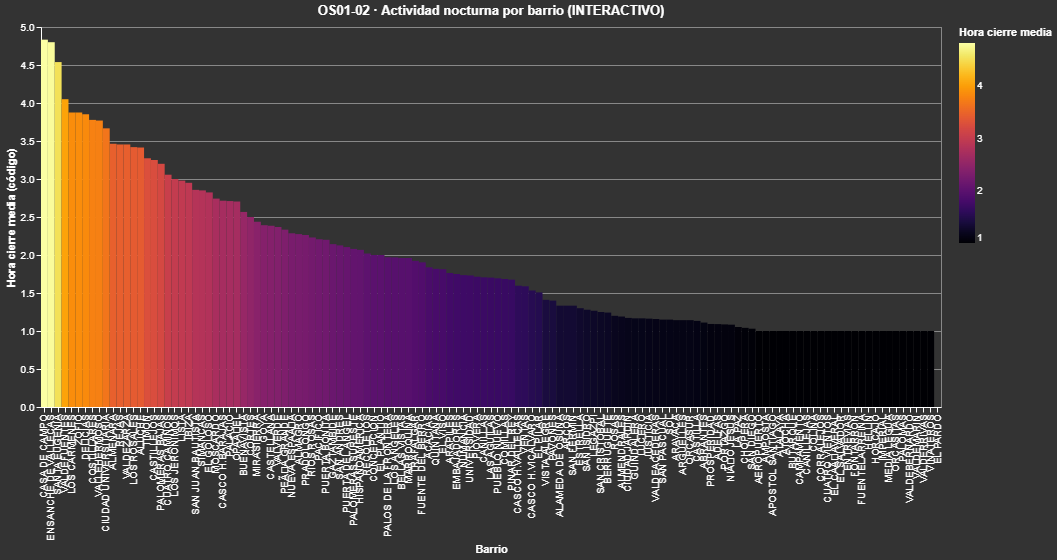

In [90]:
# Selector interactivo por barrio
select_barrio = alt.selection_point(fields=["barrio"], on="click")
hover = alt.selection_point(fields=["barrio"], on="mouseover")

chart_horarios_barrio = (
    alt.Chart(df_actividad_barrio)
    .mark_rect()
    .encode(
        x=alt.X("barrio:N", sort="-y", title="Barrio"),
        y=alt.Y("hora_cierre_media:Q", title="Hora cierre media (código)"),

        color=alt.condition(
            select_barrio | hover,
            alt.Color("hora_cierre_media:Q", scale=alt.Scale(scheme="inferno"), title="Hora cierre media"),
            alt.value("lightgray")
        ),

        opacity=alt.condition(select_barrio | hover, alt.value(1), alt.value(0.4)),

        tooltip=[
            alt.Tooltip("barrio:N", title="Barrio"),
            alt.Tooltip("hora_cierre_media:Q", title="Hora cierre media (código)"),
            alt.Tooltip("num_locales:Q", title="Locales"),
            alt.Tooltip("num_terrazas:Q", title="Terrazas")
        ]
    )
    .add_params(select_barrio, hover)
    .properties(
        width=900,
        height=380,
        title="OS01-02 · Actividad nocturna por barrio (INTERACTIVO)"
    )
    .interactive()   # Zoom + pan
)

chart_horarios_barrio

A partir de la visualización OS01‑02 - Actividad nocturna por barrio (interactivo) se aprecia un gradiente muy marcado en la intensidad de la actividad nocturna entre los distintos barrios de Madrid, ordenados de forma descendente según la hora media de cierre. 

Un reducido conjunto de barrios concentra los horarios de cierre más tardíos, representados en tonos más claros, lo que indica una mayor prolongación de la actividad nocturna y, previsiblemente, un uso más intenso del espacio público durante la noche. 

En contraste, la mayoría de los barrios se sitúa en valores intermedios o bajos, con cierres más tempranos y una actividad nocturna más limitada. 

La magnitud de este descenso progresivo sugiere que la experiencia nocturna en Madrid está fuertemente polarizada, con diferencias sustanciales entre barrios muy activos y el resto del tejido urbano. 

Esta distribución refuerza la hipótesis central del OS01: la exposición acústica y la experiencia ciudadana no son homogéneas, sino que dependen de patrones espaciales de actividad nocturna claramente diferenciados, que deben ser considerados en el análisis del impacto del ruido urbano.

### Visualización OS01-03 – Evolución temporal del ruido

TIPO DE GRÁFICOS: 
* Línea temporal interactiva de laeq según diferentes periodos de agregación (diario, semanal y mensual)
* Comparación D / E / N
* Picos semanales o estacionales

HIPÓTESIS: El ruido nocturno presenta comportamientos distintos al diurno y está vinculado a patrones de uso urbano, no solo al tráfico.  

### OS01‑03a - Evolución temporal del ruido urbano (LAeq)

Objetivo de la visualización: Analizar la evolución temporal del nivel sonoro urbano en Madrid, diferenciando los periodos diurno, vespertino y nocturno, para identificar patrones temporales y posibles cambios en la exposición acústica a lo largo del tiempo.

Tipo de gráfico (Altair‑Vega): Gráfico de líneas temporal interactivo (mark_line) con diferenciación por periodo acústico (D/E/N) y selección interactiva por leyenda y eje temporal

Justificación; El gráfico de líneas permite observar tendencias, variaciones y discontinuidades en el ruido urbano a lo largo del tiempo, mientras que la diferenciación por periodos acústicos facilita comparar cómo evoluciona la exposición en franjas horarias con distinta intensidad de uso urbano, reforzando el análisis temporal del OS01.

Datos utilizados: df_01_ruido_diario, agregados temporalmente (media de LAeq) y clasificados por periodo acústico (diurno, vespertino y nocturno).


### OS01‑03b - Picos semanales de ruido

Objetivo de la visualización: Identificar patrones cíclicos y picos recurrentes del ruido urbano a lo largo de las semanas del año, diferenciando los periodos diurno, vespertino y nocturno, para analizar la relación entre temporalidad semanal y exposición acústica.

Tipo de gráfico (Altair‑Vega): Gráfico de líneas interactivo con marcadores (mark_line con point=True), agregado semanalmente y codificado por periodo acústico (D/E/N).

Justificación: La agregación por semana permite detectar regularidades y picos sistemáticos del ruido urbano, reduciendo la variabilidad diaria y facilitando la comparación entre distintos periodos acústicos, lo que resulta clave para comprender la estructura temporal de la exposición sonora.

Datos utilizados: Datos de ruido urbano procedentes de df_01_ruido_diario, agregados a nivel semanal (LAeq medio) y clasificados por periodo acústico (diurno, vespertino y nocturno).

### OS01‑03c - Patrones estacionales del ruido urbano

Objetivo de la visualización: Identificar patrones estacionales en la exposición al ruido urbano en Madrid, analizando la variación mensual del LAeq medio y sus diferencias entre los periodos diurno, vespertino y nocturno.

Tipo de gráfico (Altair‑Vega): Gráfico de líneas interactivo (chart) con agregación mensual y codificación por periodo acústico (D/E/N).

Justificación: La agregación mensual permite reducir la variabilidad diaria y resaltar tendencias estacionales, mientras que el uso de áreas facilita la comparación visual entre periodos acústicos y evidencia cómo la intensidad del ruido se distribuye a lo largo del año.

Datos utilizados: df_01_ruido_diario, con registros diarios de ruido urbano, agregados a nivel mensual (LAeq medio) y clasificados por periodo acústico (diurno, vespertino y nocturno).

### OS01‑03d - Intensidad mensual del ruido urbano (LAeq) en Madrid

Objetivo de la visualización: Identificar patrones estacionales y cambios estructurales en la intensidad del ruido urbano en Madrid, analizando la variación mensual del nivel sonoro medio (LAeq) a lo largo del tiempo.

Tipo de gráfico (Altair‑Vega): Mapa de calor (heatmap) (mark_rect) con codificación cromática del LAeq medio mensual, organizado por año (eje vertical) y mes (eje horizontal).

Justificación: El heatmap permite sintetizar de forma visual una gran cantidad de información temporal, facilitando la detección simultánea de patrones estacionales, años anómalos y tendencias de largo plazo en la exposición acústica. A diferencia de los gráficos de líneas, esta representación resalta la distribución temporal de la intensidad del ruido, reforzando el análisis de la experiencia ciudadana cotidiana en diferentes momentos del año.

Datos utilizados: Datos de ruido urbano procedentes de df_02_cont_acustic, utilizando el indicador LAeq y agregados como media mensual por año (promedio entre estaciones de medida).

In [91]:
# ================================
# VISUALIZACIÓN 1 – EVOLUCIÓN TEMPORAL DEL RUIDO
# Altair interactivo (LAeq por periodos D/E/N)
# ================================

# ----------------------------------------------------------
# 1. Usamos tu dataframe real df_01_ruido_diario
# ----------------------------------------------------------

df = df_01_ruido_diario.copy()

# Asegurar formato fecha
df['fecha'] = pd.to_datetime(df['fecha'])

# Mapeo de periodos

df["periodo_desc"] = df["periodo"].map({
    "D": "Diurno",
    "E": "Vespertino",
    "N": "Nocturno"
})

# Filtrar solo D/E/N (comparación solicitada)
df = df[df["periodo"].isin(["D", "E", "N"])]


# ---------- AGREGACIONES ----------
df_daily = (
    df
    .groupby(["fecha", "periodo_desc"], as_index=False)
    .agg(laeq_medio=("laeq", "mean"))
)

df_daily["week"] = df_daily["fecha"].dt.isocalendar().week.astype(int)
df_daily["month"] = df_daily["fecha"].dt.month
df_daily["month_name"] = df_daily["fecha"].dt.month_name()

df_week = (
    df_daily
    .groupby(["week", "periodo_desc"], as_index=False)
    .agg(laeq_medio=("laeq_medio", "mean"))
)

df_month = (
    df_daily
    .groupby(["month", "month_name", "periodo_desc"], as_index=False)
    .agg(laeq_medio=("laeq_medio", "mean"))
)


# ----------------------------------------------------------
# 2. Selectores interactivos
# ----------------------------------------------------------

# Selección temporal con brush (sobre el eje X)
brush_time = alt.selection_interval(encodings=['x'], name='SeleccionTemporal')

# Selección multiserie por leyenda
select_period = alt.selection_point(fields=['periodo_desc'], bind='legend', name='Periodo')



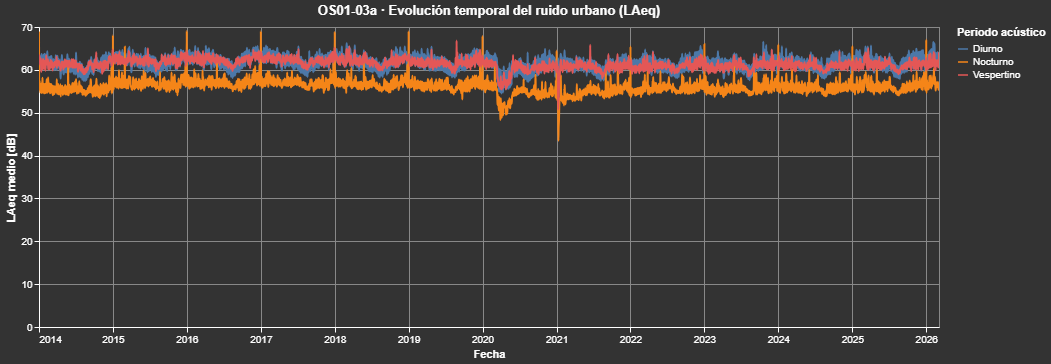

In [92]:
# ----------------------------------------------------------
# OS01-3a. Gráfico principal – Evolución temporal LAeq (D/E/N)
# INTERACTIVO
# ----------------------------------------------------------

chart_line = (
    alt.Chart(df_daily)
    .mark_line(interpolate="monotone")
    .encode(
        x=alt.X("fecha:T", title="Fecha"),
        y=alt.Y("laeq_medio:Q", title="LAeq medio [dB]"),
        color=alt.Color("periodo_desc:N", title="Periodo acústico"),
        tooltip=[
            alt.Tooltip("yearmonthdate(fecha):T", title="Fecha"),
            alt.Tooltip("laeq_medio:Q", title="LAeq medio", format=".2f"),
            alt.Tooltip("periodo_desc:N", title="Periodo")
        ]
    )
    .add_params(select_period, brush_time)   # ✅ interactividad declarativa
    .transform_filter(select_period)          # ✅ filtro por periodo
    .interactive()                            # ✅ zoom + pan
    .properties(
        width=900,
        height=300,
        title="OS01-03a · Evolución temporal del ruido urbano (LAeq)"
    )
)

chart_line

A partir de la visualización OS01‑03a · Evolución temporal del ruido urbano (LAeq) se observa que el ruido ambiental en Madrid presenta un comportamiento relativamente estable en el largo plazo, con diferencias persistentes entre los periodos diurno, vespertino y nocturno. El periodo diurno mantiene de forma sistemática los niveles más elevados de LAeq, seguido del vespertino, mientras que el nocturno registra valores más bajos pero notablemente constantes, lo que sugiere una presencia estructural del ruido incluso en las horas de menor actividad. Asimismo, se identifican variaciones puntuales y descensos temporales, especialmente visibles en determinados intervalos concretos, que podrían estar asociados a cambios excepcionales en la actividad urbana. En conjunto, la visualización pone de manifiesto que la exposición acústica en Madrid no es un fenómeno aislado ni episódico, sino un rasgo persistente del entorno urbano, cuya evolución temporal y diferenciación horaria son fundamentales para comprender la experiencia ciudadana y su impacto en la calidad de vida, en coherencia con los objetivos del OS01.

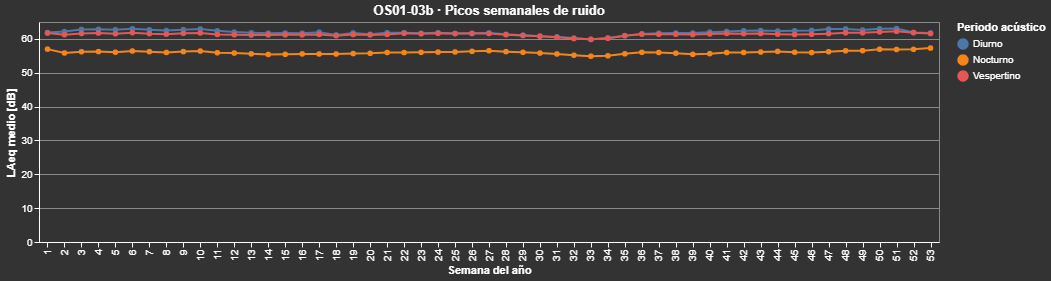

In [93]:
# OS01-03b · Picos semanales de ruido (INTERACTIVO, eje Y desde 0 dB)

chart_week = (
    alt.Chart(df_week)
    .mark_line(point=True)
    .encode(
        x=alt.X("week:O", title="Semana del año"),
        y=alt.Y(
            "laeq_medio:Q",
            title="LAeq medio [dB]",
            scale=alt.Scale(zero=True)   # ✅ el eje empieza en 0 dB
        ),
        color=alt.Color(
            "periodo_desc:N",
            title="Periodo acústico"
        ),
        tooltip=[
            alt.Tooltip("week:O", title="Semana"),
            alt.Tooltip("laeq_medio:Q", title="LAeq medio", format=".2f"),
            alt.Tooltip("periodo_desc:N", title="Periodo")
        ]
    )
    .interactive()
    .properties(
        width=900,
        height=220,
        title="OS01-03b · Picos semanales de ruido"
    )
)

chart_week

A partir de la visualización OS01‑03b · Picos semanales de ruido, se observa que el ruido urbano en Madrid presenta patrones semanales regulares y consistentes a lo largo del año, diferenciados claramente por periodo acústico. Los niveles medios de ruido diurno y vespertino se mantienen sistemáticamente más elevados que el nocturno, mostrando variaciones moderadas pero recurrentes entre semanas, lo que indica una estructura temporal estable vinculada a los ritmos de actividad urbana. El ruido nocturno, aunque menor en términos absolutos, también evidencia oscilaciones semanales persistentes, lo que sugiere que la exposición acústica durante la noche no es puntual ni excepcional, sino un fenómeno continuo. En conjunto, la visualización refuerza la idea de que el ruido urbano responde a dinámicas temporales cíclicas, más que a episodios aislados, aportando evidencia clave para comprender la exposición acústica como parte estructural de la experiencia ciudadana en Madrid, en coherencia con los objetivos del OS01.

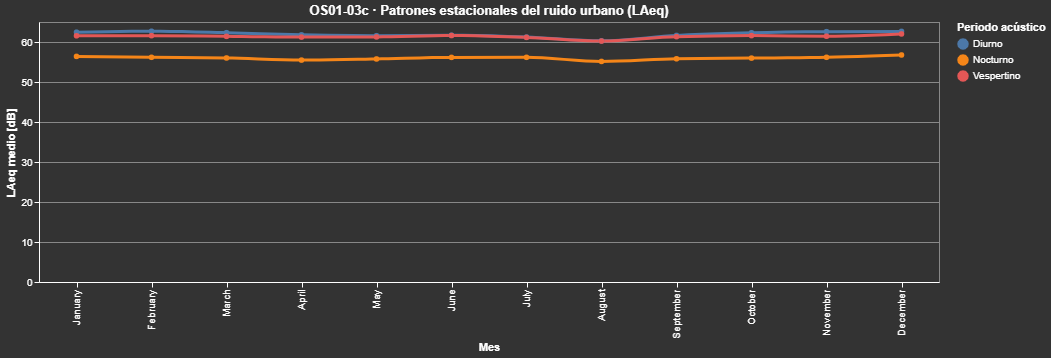

In [94]:
# OS01-03c · Patrones estacionales del ruido (LÍNEAS)

chart_month = (
    alt.Chart(df_month)
    .mark_line(
        interpolate="monotone",
        strokeWidth=3,
        point=True
    )
    .encode(
        x=alt.X(
            "month_name:N",
            sort=[
                "January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December"
            ],
            title="Mes"
        ),
        y=alt.Y(
            "laeq_medio:Q",
            title="LAeq medio [dB]",
            scale=alt.Scale(zero=True)
        ),
        color=alt.Color(
            "periodo_desc:N",
            title="Periodo acústico"
        ),
        tooltip=[
            alt.Tooltip("month_name:N", title="Mes"),
            alt.Tooltip("periodo_desc:N", title="Periodo"),
            alt.Tooltip("laeq_medio:Q", title="LAeq medio", format=".2f")
        ]
    )
    .interactive()   # ✅ interactividad (zoom + pan)
    .properties(
        width=900,
        height=260,
        title="OS01-03c - Patrones estacionales del ruido urbano (LAeq)"
    )
)

chart_month

A partir de la visualización OS01‑03c - Patrones estacionales del ruido urbano, se observa que la exposición acústica en Madrid presenta variaciones estacionales claras y consistentes a lo largo del año, diferenciadas por periodo acústico. 
Los niveles de LAeq medio tienden a incrementarse durante los meses centrales, especialmente en los periodos diurno y vespertino, lo que sugiere una intensificación de la actividad urbana asociada a condiciones climáticas más favorables y a un mayor uso del espacio público. Por el contrario, en los meses invernales se aprecia una ligera reducción del ruido, aunque el periodo nocturno mantiene valores relativamente estables, evidenciando que el ruido nocturno constituye un fenómeno persistente incluso en épocas de menor actividad general. 

En conjunto, la visualización pone de manifiesto que el ruido urbano no solo depende de patrones diarios o semanales, sino que también está condicionado por dinámicas estacionales, lo que refuerza la necesidad de incorporar la dimensión temporal larga en el análisis de la exposición acústica y su impacto en la experiencia ciudadana, en coherencia con los objetivos del OS01.

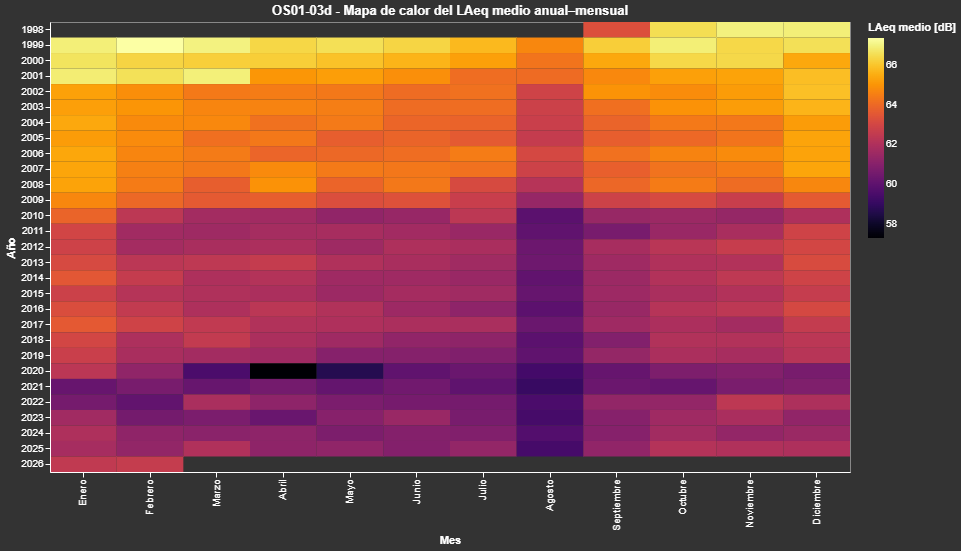

In [13]:
# OS01‑03d - Intensidad mensual del ruido urbano (LAeq) en Madrid
# --------------------------------------------------------
# PREPARACIÓN DE DATOS
# --------------------------------------------------------

df_heatmap = (
    df_02_cont_acustic
    .dropna(subset=["laeq"])
    .groupby(["year", "month", "month_name"], as_index=False)
    .agg(
        laeq_medio=("laeq", "mean")
    )
)

# ----------------------------------------------------------
# VISUALIZACIÓN · Heatmap año-mes del LAeq
# ----------------------------------------------------------

chart_heatmap = (
    alt.Chart(df_heatmap)
    .mark_rect()
    .encode(
        x=alt.X(
            "month_name:N",
            sort=[
                "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
                "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
            ],
            title="Mes"
        ),
        y=alt.Y(
            "year:O",
            title="Año"
        ),
        color=alt.Color(
            "laeq_medio:Q",
            title="LAeq medio [dB]",
            scale=alt.Scale(scheme="inferno")
        ),
        tooltip=[
            alt.Tooltip("year:O", title="Año"),
            alt.Tooltip("month_name:N", title="Mes"),
            alt.Tooltip("laeq_medio:Q", title="LAeq medio [dB]", format=".2f")
        ]
    )
    .properties(
        width=800,
        height=450,
        title="OS01-03d - Mapa de calor del LAeq medio anual–mensual"
    )
)

chart_heatmap

La visualización OS01‑03d pone de manifiesto patrones estacionales claros en la intensidad del ruido urbano en Madrid, destacando una disminución recurrente del nivel sonoro durante el mes de agosto, coherente con la reducción de la actividad laboral y del tráfico asociada al periodo vacacional. 

Este descenso estacional se observa de forma consistente a lo largo de los años, lo que refuerza la relación entre uso del espacio urbano y presión acústica.

Asimismo, el mapa de calor permite identificar una reducción acusada y generalizada del ruido durante el periodo del confinamiento asociado a la pandemia de COVID‑19, visible como un cambio estructural respecto a los años anteriores y posteriores. Esta anomalía temporal constituye un ejemplo claro de cómo las restricciones a la movilidad y a la actividad urbana tienen un impacto directo e inmediato sobre los niveles de ruido ambiental.


En conjunto, la visualización confirma que la exposición acústica en la ciudad responde tanto a dinámicas estacionales recurrentes como a eventos excepcionales de carácter estructural, reforzando el objetivo del OS01 al analizar el ruido urbano como un componente clave de la experiencia ciudadana, sensible a los cambios en los patrones de actividad y uso del espacio público.

En conjunto, las visualizaciones OS01‑03 ponen de manifiesto que la exposición al ruido urbano en Madrid es un fenómeno estructural y persistente, con patrones temporales claramente definidos. 

La evolución diaria muestra una estabilidad general del ruido por periodos acústicos, mientras que el análisis semanal revela ciclos recurrentes de mayor y menor intensidad asociados a los ritmos de actividad urbana. 

A su vez, los patrones estacionales evidencian variaciones moderadas a lo largo del año, con incrementos en los meses centrales, sin que ello suponga una reducción significativa del ruido nocturno. 

Estos resultados refuerzan la idea de que la experiencia acústica ciudadana está condicionada por dinámicas temporales regulares —diarias, semanales y estacionales— que deben ser consideradas de forma integrada en el análisis del ruido urbano.

### Visualización OS01-04 – Ruido NOCTURNO + actividad urbana
OBJETIVO: Correlacionar el ruido nocturno (obtenido del laeq nocturno) con la actividad urbana (entendida como hora_cierre_media de los locales)
Y comparar las medidas por barrios.

TIPO DE GRÁFICO: Scatter plot o small multiples

Hipótesis: La intensidad nocturna del ocio presenta correlación con niveles acústicos elevados.

Enfoque metodológico del gráfico:

* Unidad de análisis: barrio
* Variable X: hora_cierre_media (aproximación de intensidad nocturna del ocio)
* Variable Y: Ln (ruido ambiental nocturno)
* Tamaño del punto: nº de locales 
* Color: barrio (o densidad de locales)
* Datos pre‑agregados por barrio para reducir el volumen de datos en el notebook

In [95]:
df_06_locales.head()

,id_local,rotulo_local,id_terraza,rotulo_terraza,distrito,barrio,cod_barrio_local,seccion_censal,latitud,longitud,superficie_es,superficie_ra,mesas_es,mesas_ra,sillas_es,sillas_ra,desc_periodo_terraza,desc_situacion_terraza,hora_cierre_num,desc_tipo_acceso_local_local,desc_situacion_local_local,cod_postal_local,cod_postal_terraza,fx_carga_local,fx_carga_terraza,longitud_wgs84,latitud_wgs84,hora_cierre_real
0,10000003,VITACA,2038.0,VITACA,CENTRO,JUSTICIA,4.0,1088.0,4475338.53,440554.59,6.48,6.48,2.0,2.0,8.0,8.0,Anual,Abierta,NaN,Puerta Calle,Abierto,28004.0,28004.0,2026-03-05,2026-05-03,-3.700788,40.426558,NaN
1,10000004,ZAATAR & CO,19621.0,ZAATAR & CO,CENTRO,UNIVERSIDAD,5.0,1106.0,4475591.53,439945.60,7.02,7.02,3.0,3.0,9.0,9.0,Anual,Abierta,2.0,Puerta Calle,Abierto,28015.0,28015.0,2026-03-05,2026-05-03,-3.707991,40.428794,NaN
2,10000013,HOTEL MEDIODIA,NaN,NaN,CENTRO,EMBAJADORES,2.0,1058.0,4473326.52,441199.58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Puerta Calle,Abierto,28012.0,NaN,2026-03-05,NaN,-3.692999,40.408479,NaN
3,10000044,V.M. VINOMANIA,NaN,NaN,CENTRO,PALACIO,1.0,1014.0,4473550.53,439722.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Puerta Calle,Cerrado,28005.0,NaN,2026-03-05,NaN,-3.710426,40.410391,NaN
4,10000052,MUNE,NaN,NaN,CENTRO,JUSTICIA,4.0,1082.0,4475142.52,440875.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Puerta Calle,Abierto,28004.0,NaN,2026-03-05,NaN,-3.696986,40.424816,NaN


id_terraza es el único indicador consistente de existencia de terraza.
* Se cuentan terrazas por barrio.
* Se alinea con “actividad nocturna exterior”.

Refuerza la hipótesis ruido–ocio
Evita errores por NaNs estructurales de mesas/sillas.

El número de terrazas por barrio se estimó a partir del identificador de terraza presente en el dataset de locales, contabilizando aquellas observaciones con terraza asociada. Esta aproximación permite medir la intensidad del ocio exterior de forma consistente, evitando problemas derivados de información incompleta sobre mesas o sillas.

El ruido nocturno se caracterizó a partir del indicador Ln, asociado a cada estación acústica. 
La asignación espacial a barrios se realizó mediante la vinculación de cada estación con su barrio correspondiente, permitiendo obtener un nivel medio de ruido nocturno a escala de barrio.

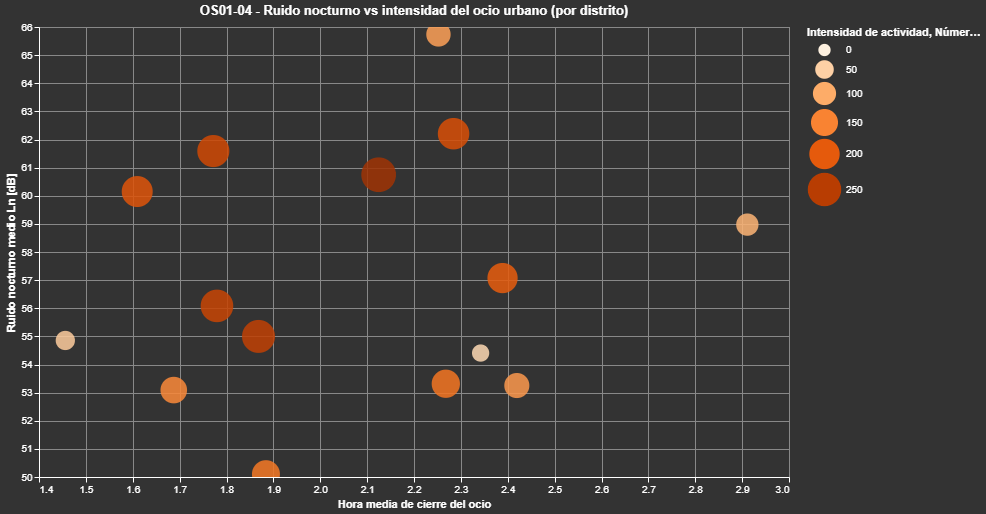

In [96]:
# =========================================================
# OS01 · VISUALIZACIÓN 04
# Ruido nocturno vs intensidad del ocio (POR DISTRITO)
# =========================================================

# ---------------------------------------------------------
# 0. Función de normalización de texto (CLAVE)
# ---------------------------------------------------------
def normaliza_texto(s):
    if pd.isna(s):
        return s
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return s.upper().strip()

# =========================================================
# 1. ACTIVIDAD URBANA NOCTURNA → DISTRITO
# =========================================================

df_act = df_06_locales.copy()

# Mapeo correcto de hora de cierre
mapa_horas = {12: 23, 13: 24, 14: 1, 15: 2, 16: 3}

df_act = df_act[df_act["hora_cierre_num"].isin(mapa_horas)]
df_act["hora_cierre_real"] = df_act["hora_cierre_num"].map(mapa_horas)

# Agregado por distrito
df_actividad_distrito = (
    df_act
    .groupby("distrito", as_index=False)
    .agg(
        hora_cierre_media=("hora_cierre_real", "mean"),
        num_locales=("id_local", "nunique"),
        num_terrazas=("id_terraza", lambda x: x.notna().sum())
    )
)

df_actividad_distrito["distrito_norm"] = df_actividad_distrito["distrito"].apply(normaliza_texto)

# =========================================================
# 2. RUIDO NOCTURNO (Ln) → DISTRITO
# =========================================================

df_ruido = df_02_cont_acustic.copy()

# Ruido nocturno: Ln ≠ NaN
df_ruido = df_ruido[df_ruido["ln"].notna()]

# Añadir distrito desde estaciones
df_ruido = df_ruido.merge(
    df_05_est_ac[["estacion", "distrito"]],
    on="estacion",
    how="left"
)

# Agregado por distrito
df_ruido_distrito = (
    df_ruido
    .groupby("distrito", as_index=False)
    .agg(
        laeq_nocturno=("ln", "mean")
    )
)

df_ruido_distrito["distrito_norm"] = df_ruido_distrito["distrito"].apply(normaliza_texto)

# =========================================================
# 3. DATASET FINAL INTEGRADO (ROBUSTO)
# =========================================================

df_corr_distrito = (
    df_actividad_distrito
    .merge(
        df_ruido_distrito,
        on="distrito_norm",
        how="inner",
        suffixes=("_act", "_ruido")
    )
)

# =========================================================
# 4. SCATTER FINAL
# =========================================================

scatter_nocturno = (
    alt.Chart(df_corr_distrito)
    .mark_circle(opacity=0.85)
    .encode(
        x=alt.X(
            "hora_cierre_media:Q",
            title="Hora media de cierre del ocio",
            scale=alt.Scale(zero=False)
        ),
        y=alt.Y(
            "laeq_nocturno:Q",
            title="Ruido nocturno medio Ln [dB]",
            scale=alt.Scale(zero=False)
        ),
        size=alt.Size(
            "num_locales:Q",
            title="Número de locales",
            scale=alt.Scale(range=[150, 1200])
        ),
        color=alt.Color(
            "num_locales:Q",
            title="Intensidad de actividad",
            scale=alt.Scale(scheme="oranges")
        ),
        tooltip=[
            alt.Tooltip("distrito_act:N", title="Distrito"),
            alt.Tooltip("hora_cierre_media:Q", format=".2f"),
            alt.Tooltip("laeq_nocturno:Q", format=".1f"),
            alt.Tooltip("num_locales:Q", title="Locales"),
            alt.Tooltip("num_terrazas:Q", title="Terrazas")
        ]
    )
    .interactive()
    .properties(
        width=750,
        height=450,
        title="OS01-04 - Ruido nocturno vs intensidad del ocio urbano (por distrito)"
    )
)

scatter_nocturno

La correlación entre actividad nocturna y ruido se analiza a nivel de distrito, dado que las estaciones acústicas no se corresponden de forma unívoca con los límites administrativos de barrio. Para garantizar la coherencia espacial entre fuentes, se realizó una normalización previa de los nombres de distrito y se agregaron los indicadores antes de su integración.

### Visualización OS01-05 – Ruido y calidad de vida (alto nivel)
El ruido es un factor ambiental que influye indirectamente en la percepción de calidad de vida urbana.
* OBJETIVO: Se busca correspondencia temporal y contexto.

Para la representación se utiliza:  
* Evolución de calidad de vida en Madrid.
* Comparativa con ruido a lo largo de los años.

Escala: ciudad de Madrid (no intraurbana)
Unidad temporal: año
DATOS:
* Ruido → LAeq medio anual (exposición acústica)
* Calidad de vida → índice agregado / percepción media



TIPO DE GRÁFICO: Gráfico combinado de líneas (dual‑axis, conceptualmente) interactivo
* Línea 1: Evolución del ruido medio anual
* Línea 2: Evolución del índice de calidad de vida
Ambas sobre el mismo eje temporal

En Altair se utilizan: líneas superpuestas, paneles sincronizados y capas con escalas independientes claramente etiquetadas

🔴 Línea roja → Ruido medio anual [dB]
🔵 Línea azul → Índice de calidad de vida

* La Visualización OS01-05 muestra de forma conjunta la evolución del ruido urbano y la percepción agregada de la calidad de vida. 
* La línea roja representa el nivel medio anual de ruido, mientras que la línea azul corresponde al índice de calidad de vida.
* La comparación temporal permite contextualizar el ruido como un factor ambiental que influye indirectamente en la experiencia urbana y el bienestar percibido.

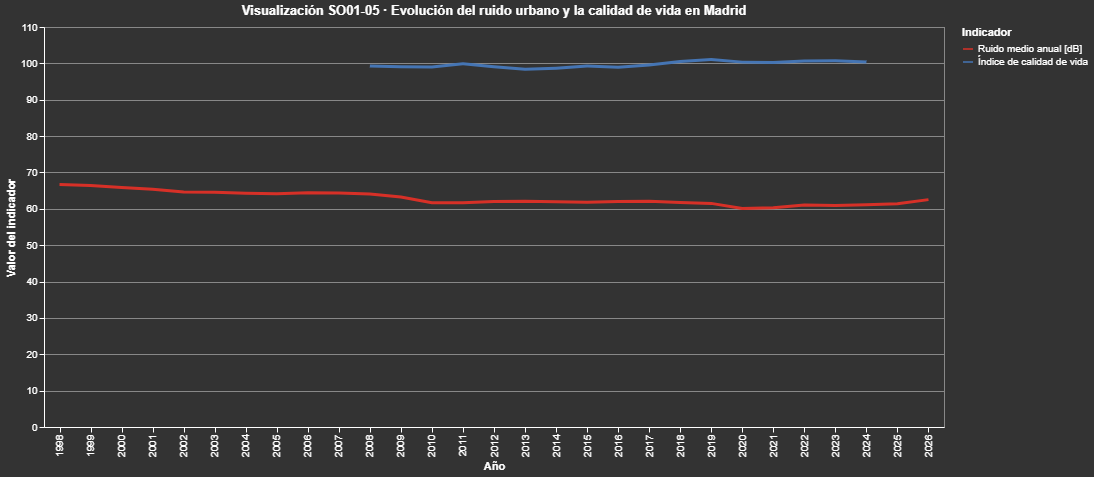

In [97]:
# =========================================================
# VISUALIZACIÓN OS01-05 · RUIDO y CALIDAD DE VIDA (ALTO NIVEL)
# =========================================================

# ---------------------------------------------------------
# 1. RUIDO MEDIO ANUAL (Madrid)
# ---------------------------------------------------------
df_ruido_anual = (
    df_02_cont_acustic
    .dropna(subset=["laeq"])
    .groupby("year", as_index=False)
    .agg(
        ruido_medio=("laeq", "mean")
    )
)

df_ruido_anual["Indicador"] = "Ruido medio anual [dB]"
df_ruido_anual = df_ruido_anual.rename(columns={"ruido_medio": "valor"})

# ---------------------------------------------------------
# 2. CALIDAD DE VIDA (Madrid / Total Nacional)
# ---------------------------------------------------------
df_calidad_vida = (
    df_07_Q_vida
    .query("CCAA == 'Madrid, Comunidad de'")   # en la Comunidad de Madrid
    .drop(columns=["CCAA"])
    .melt(var_name="year", value_name="valor")
)

# .query("CCAA == 'Total Nacional'") 
# .query("CCAA == 'Madrid, Comunidad de'")   


df_calidad_vida["year"] = df_calidad_vida["year"].astype(int)
df_calidad_vida["Indicador"] = "Índice de calidad de vida"

# ---------------------------------------------------------
# 3. DATASET COMBINADO (FORMATO LARGO)
# ---------------------------------------------------------
df_ruido_calidad_long = pd.concat(
    [df_ruido_anual[["year", "valor", "Indicador"]],
     df_calidad_vida[["year", "valor", "Indicador"]]],
    ignore_index=True
)

# ---------------------------------------------------------
# 4. VISUALIZACIÓN FINAL CON LEYENDA + INTERACTIVIDAD
# ---------------------------------------------------------
visualizacion_5 = (
    alt.Chart(df_ruido_calidad_long)
    .mark_line(strokeWidth=3)
    .encode(
        x=alt.X("year:O", title="Año"),
        y=alt.Y("valor:Q", title="Valor del indicador"),
        color=alt.Color(
            "Indicador:N",
            title="Indicador",
            scale=alt.Scale(
                domain=[
                    "Ruido medio anual [dB]",
                    "Índice de calidad de vida"
                ],
                range=["#d73027", "#4575b4"]  # rojo / azul
            )
        ),
        tooltip=[
            alt.Tooltip("year:O", title="Año"),
            alt.Tooltip("Indicador:N", title="Indicador"),
            alt.Tooltip("valor:Q", title="Valor", format=".2f")
        ]
    )
    .interactive()   # ✅ INTERACTIVIDAD
    .properties(
        width=900,
        height=400,
        title="Visualización SO01-05 · Evolución del ruido urbano y la calidad de vida en Madrid"
    )
)

visualizacion_5

A partir de la visualización OS01‑05 - Ruido y calidad de vida (alto nivel) se observa que la evolución del ruido urbano medio anual en Madrid se mantiene relativamente estable, con ligeras oscilaciones a lo largo del periodo analizado, mientras que el índice de calidad de vida muestra una tendencia también bastante constante. 

No se aprecia una correspondencia directa ni inmediata entre variaciones del ruido y cambios bruscos en la calidad de vida, lo que sugiere que el ruido actúa como un factor ambiental estructural más que como un determinante aislado del bienestar percibido. 

La visualización permite contextualizar que, aunque el ruido forma parte de la experiencia urbana y puede influir indirectamente en la calidad de vida, esta última responde a un conjunto más amplio de factores sociales, económicos y ambientales, reforzando una interpretación prudente y no causal de la relación entre ambas variables.

In [ ]:
%whos